In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv('Churn_Modelling (2).csv')
x=df.iloc[:,3:13].values
y=df.iloc[:,13].values

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
x

array([[619, 'France', 'Female', ..., 1, 1, 101348.88],
       [608, 'Spain', 'Female', ..., 0, 1, 112542.58],
       [502, 'France', 'Female', ..., 1, 0, 113931.57],
       ...,
       [709, 'France', 'Female', ..., 0, 1, 42085.58],
       [772, 'Germany', 'Male', ..., 1, 0, 92888.52],
       [792, 'France', 'Female', ..., 1, 0, 38190.78]], dtype=object)

In [9]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
labelencoder_x_1=LabelEncoder()
x[:,1]=labelencoder_x_1.fit_transform(x[:,1])
labelencoder_x_2=LabelEncoder()
x[:,2]=labelencoder_x_2.fit_transform(x[:,2])

In [10]:
x

array([[619, 0, 0, ..., 1, 1, 101348.88],
       [608, 2, 0, ..., 0, 1, 112542.58],
       [502, 0, 0, ..., 1, 0, 113931.57],
       ...,
       [709, 0, 0, ..., 0, 1, 42085.58],
       [772, 1, 1, ..., 1, 0, 92888.52],
       [792, 0, 0, ..., 1, 0, 38190.78]], dtype=object)

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=0)

In [12]:
len(df)

10000

In [13]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [14]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier()
clf.fit(x_train,y_train)
pred=clf.predict(x_test)

In [15]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred)
print(cm)

[[1366  229]
 [ 184  221]]


In [16]:
from sklearn.metrics import accuracy_score,classification_report
print(classification_report(y_test,pred))
print(accuracy_score(y_test,pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1595
           1       0.49      0.55      0.52       405

    accuracy                           0.79      2000
   macro avg       0.69      0.70      0.69      2000
weighted avg       0.80      0.79      0.80      2000

0.7935


In [17]:
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier()
clf.fit(x_train,y_train)
pred=clf.predict(x_test)

In [18]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred)
print(cm)

[[1523   72]
 [ 198  207]]


In [19]:
from sklearn.metrics import accuracy_score,classification_report
print(classification_report(y_test,pred))
print(accuracy_score(y_test,pred))


              precision    recall  f1-score   support

           0       0.88      0.95      0.92      1595
           1       0.74      0.51      0.61       405

    accuracy                           0.86      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.86      0.86      0.86      2000

0.865


In [20]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [21]:
classifier=Sequential()
classifier.add(Dense(units=6,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier.add(Dense(units=6,kernel_initializer='uniform',activation='relu'))
classifier.add(Dense(units=6,kernel_initializer='uniform',activation='relu'))
classifier.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))

In [22]:
#compiling the ANN
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]

np.int64(0)

In [23]:
classifier.fit(x_train,y_train,batch_size=100,epochs=20)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7954 - loss: 0.6783
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.6063
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4733
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4466
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4416
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4378
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4352
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4336
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4324
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4314
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4302
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8030 - lo

In [24]:
y_pred_ann=classifier.predict(x_test)
y_pred_ann=(y_pred_ann>0.5)
cm3=confusion_matrix(y_test,y_pred_ann)
print(cm3)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1551   44]
 [ 271  134]]


In [25]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann))

0.8425


In [26]:
#Create Model A with 1 hidden layer
classifier_model_A=Sequential()
classifier_model_A.add(Dense(units=6,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_A.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))

In [27]:
#compiling the ANN
classifier_model_A.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]

np.int64(0)

In [28]:
classifier_model_A.fit(x_train,y_train,batch_size=100,epochs=20)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7804 - loss: 0.6749
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.6142
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.5341
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4735
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7965 - loss: 0.4454
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7995 - loss: 0.4332
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8033 - loss: 0.4261
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8051 - loss: 0.4208
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8065 - loss: 0.4163
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8086 - loss: 0.4123
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8115 - loss: 0.4085
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8127 - lo

In [29]:
y_pred_ann1=classifier_model_A.predict(x_test)
y_pred_ann1=(y_pred_ann1>0.5)
cm4=confusion_matrix(y_test,y_pred_ann1)
print(cm4)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1591    4]
 [ 354   51]]


In [30]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann1))

0.821


In [31]:
#Create Model B with 2 hidden layer
classifier_model_B=Sequential()
classifier_model_B.add(Dense(units=6,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=6,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))

In [32]:
classifier_model_B.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]

np.int64(0)

In [33]:
history_relu = classifier_model_B.fit(x_train,y_train,batch_size=100,epochs=20)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7905 - loss: 0.6769
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.5932
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4750
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4480
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7960 - loss: 0.4421
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7960 - loss: 0.4388
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4368
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4354
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4343
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4336
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4327
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - lo

In [34]:
y_pred_ann2=classifier_model_B.predict(x_test)
y_pred_ann2=(y_pred_ann2>0.5)
cm5=confusion_matrix(y_test,y_pred_ann2)
print(cm5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1595    0]
 [ 405    0]]


In [35]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann2))

0.7975


In [36]:
#Create Model D with 5 hidden layer
classifier_model_D=Sequential()
classifier_model_D.add(Dense(units=6,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_D.add(Dense(units=6,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_D.add(Dense(units=6,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_D.add(Dense(units=6,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_D.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))

In [37]:
classifier_model_D.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]

np.int64(0)

In [38]:
classifier_model_D.fit(x_train,y_train,batch_size=100,epochs=20)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7950 - loss: 0.6770
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.6038
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4780
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4533
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4461
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4413
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4381
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4358
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4341
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4325
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4307
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - lo

In [39]:
y_pred_ann3=classifier_model_D.predict(x_test)
y_pred_ann3=(y_pred_ann3>0.5)
cm6=confusion_matrix(y_test,y_pred_ann3)
print(cm6)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1578   17]
 [ 341   64]]


In [40]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann3))

0.821


In [41]:
from sklearn.metrics import accuracy_score
print(f"Accuracy (3 Hidden Layers): {accuracy_score(y_test,y_pred_ann)}")
print(f"Accuracy (1 Hidden Layer): {accuracy_score(y_test,y_pred_ann1)}")
print(f"Accuracy (2 Hidden Layers): {accuracy_score(y_test,y_pred_ann2)}")
print(f"Accuracy (5 Hidden Layers): {accuracy_score(y_test,y_pred_ann3)}")

Accuracy (3 Hidden Layers): 0.8425
Accuracy (1 Hidden Layer): 0.821
Accuracy (2 Hidden Layers): 0.7975
Accuracy (5 Hidden Layers): 0.821


In [42]:
#Create Model B with 2 hidden layer
classifier_model_B1=Sequential()
classifier_model_B1.add(Dense(units=4,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B1.add(Dense(units=4,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B1.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))

In [43]:
classifier_model_B1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]

np.int64(0)

In [44]:
classifier_model_B1.fit(x_train,y_train,batch_size=100,epochs=20)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7960 - loss: 0.6764
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.5994
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4908
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4510
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4436
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4404
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4383
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7960 - loss: 0.4369
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4360
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4349
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4343
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - lo

In [45]:
y_pred_ann21=classifier_model_B1.predict(x_test)
y_pred_ann21=(y_pred_ann21>0.5)
cm5=confusion_matrix(y_test,y_pred_ann21)
print(cm5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1595    0]
 [ 405    0]]


In [46]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann21))

0.7975


In [47]:
#Create Model B with 2 hidden layer
classifier_model_B2=Sequential()
classifier_model_B2.add(Dense(units=8,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B2.add(Dense(units=8,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B2.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))
classifier_model_B2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B2.fit(x_train,y_train,batch_size=100,epochs=20)
y_pred_ann22=classifier_model_B2.predict(x_test)
y_pred_ann22=(y_pred_ann22>0.5)
cm5=confusion_matrix(y_test,y_pred_ann22)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann22))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7918 - loss: 0.6713
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.5395
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4478
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4391
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4362
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4343
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4332
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4320
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4311
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4302
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4287
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - lo

In [48]:
#Create Model B with 2 hidden layer
classifier_model_B3=Sequential()
classifier_model_B3.add(Dense(units=16,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B3.add(Dense(units=16,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B3.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))
classifier_model_B3.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B3.fit(x_train,y_train,batch_size=100,epochs=20)
y_pred_ann23=classifier_model_B3.predict(x_test)
y_pred_ann23=(y_pred_ann23>0.5)
cm5=confusion_matrix(y_test,y_pred_ann23)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann23))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7959 - loss: 0.6419
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4643
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4385
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4340
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4311
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4287
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4258
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8104 - loss: 0.4230
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8207 - loss: 0.4203
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8269 - loss: 0.4178
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8280 - loss: 0.4159
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8309 - lo

In [49]:


#Create Model B with 2 hidden layer
classifier_model_B4=Sequential()
classifier_model_B4.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B4.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B4.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))
classifier_model_B4.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B4.fit(x_train,y_train,batch_size=100,epochs=50)
y_pred_ann24=classifier_model_B4.predict(x_test)
y_pred_ann24=(y_pred_ann24>0.5)
cm5=confusion_matrix(y_test,y_pred_ann24)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann24))

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7931 - loss: 0.6098
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4422
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7960 - loss: 0.4319
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8001 - loss: 0.4259
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8240 - loss: 0.4198
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8321 - loss: 0.4141
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8321 - loss: 0.4096
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8338 - loss: 0.4056
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8347 - loss: 0.4028
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8346 - loss: 0.4008
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8353 - loss: 0.3992
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8356 - l

In [50]:
#Create Model B with 2 hidden layer
classifier_model_B=Sequential()
classifier_model_B.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))
classifier_model_B.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B.fit(x_train,y_train,batch_size=100,epochs=20)
y_pred_ann25=classifier_model_B.predict(x_test)
y_pred_ann25=(y_pred_ann25>0.5)
cm5=confusion_matrix(y_test,y_pred_ann25)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann25))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7947 - loss: 0.5456
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7960 - loss: 0.4353
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4280
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8110 - loss: 0.4218
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8300 - loss: 0.4147
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8317 - loss: 0.4101
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8329 - loss: 0.4052
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8347 - loss: 0.4028
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8341 - loss: 0.3991
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8366 - loss: 0.3975
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8353 - loss: 0.3948
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8403 - lo

In [51]:
print(f"Accuracy (Model B5 - 2 Hidden Layers, 4 units): {accuracy_score(y_test,y_pred_ann21)}")
print(f"Accuracy (Model B5 - 2 Hidden Layers, 8 units): {accuracy_score(y_test,y_pred_ann22)}")
print(f"Accuracy (Model B5 - 2 Hidden Layers, 16 units): {accuracy_score(y_test,y_pred_ann23)}")
print(f"Accuracy (Model B5 - 2 Hidden Layers, 32 units): {accuracy_score(y_test,y_pred_ann24)}")
print(f"Accuracy (Model B5 - 2 Hidden Layers, 64 units): {accuracy_score(y_test,y_pred_ann25)}")

Accuracy (Model B5 - 2 Hidden Layers, 4 units): 0.7975
Accuracy (Model B5 - 2 Hidden Layers, 8 units): 0.829
Accuracy (Model B5 - 2 Hidden Layers, 16 units): 0.841
Accuracy (Model B5 - 2 Hidden Layers, 32 units): 0.8555
Accuracy (Model B5 - 2 Hidden Layers, 64 units): 0.864


### Model B with Sigmoid Activation Function

In [52]:
# Create Model B with 2 hidden layers using 'sigmoid' activation
classifier_model_B_sigmoid = Sequential()
classifier_model_B_sigmoid.add(Dense(units=6, kernel_initializer='uniform', activation='sigmoid', input_dim=10))
classifier_model_B_sigmoid.add(Dense(units=6, kernel_initializer='uniform', activation='sigmoid'))
classifier_model_B_sigmoid.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

classifier_model_B_sigmoid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_sigmoid = classifier_model_B_sigmoid.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_ann_sigmoid = classifier_model_B_sigmoid.predict(x_test)
y_pred_ann_sigmoid = (y_pred_ann_sigmoid > 0.5)

accuracy_sigmoid = accuracy_score(y_test, y_pred_ann_sigmoid)
cm_sigmoid = confusion_matrix(y_test, y_pred_ann_sigmoid)

print(f"Confusion Matrix (Sigmoid):\n{cm_sigmoid}")
print(f"Accuracy (Model B - Sigmoid Activation): {accuracy_sigmoid}")
print(f"Final Training Loss (Sigmoid): {history_sigmoid.history['loss'][-1]:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Sigmoid):
[[1595    0]
 [ 405    0]]
Accuracy (Model B - Sigmoid Activation): 0.7975
Final Training Loss (Sigmoid): 0.4556


In [53]:
# Create Model B with 2 hidden layers using 'tanh' activation
classifier_model_B_tanh = Sequential()
classifier_model_B_tanh.add(Dense(units=6, kernel_initializer='uniform', activation='tanh', input_dim=10))
classifier_model_B_tanh.add(Dense(units=6, kernel_initializer='uniform', activation='tanh'))
classifier_model_B_tanh.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

classifier_model_B_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_tanh = classifier_model_B_tanh.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_ann_tanh = classifier_model_B_tanh.predict(x_test)
y_pred_ann_tanh = (y_pred_ann_tanh > 0.5)

accuracy_tanh = accuracy_score(y_test, y_pred_ann_tanh)
cm_tanh = confusion_matrix(y_test, y_pred_ann_tanh)

print(f"Confusion Matrix (Tanh):\n{cm_tanh}")
print(f"Accuracy (Model B - Tanh Activation): {accuracy_tanh}")
print(f"Final Training Loss (Tanh): {history_tanh.history['loss'][-1]:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Confusion Matrix (Tanh):
[[1535   60]
 [ 308   97]]
Accuracy (Model B - Tanh Activation): 0.816
Final Training Loss (Tanh): 0.4335


In [54]:
from keras.layers import ELU

# Create Model B with 2 hidden layers using 'elu' activation
classifier_model_B_elu = Sequential()
classifier_model_B_elu.add(Dense(units=6, kernel_initializer='uniform', input_dim=10))
classifier_model_B_elu.add(ELU())
classifier_model_B_elu.add(Dense(units=6, kernel_initializer='uniform'))
classifier_model_B_elu.add(ELU())
classifier_model_B_elu.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

classifier_model_B_elu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_elu = classifier_model_B_elu.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_ann_elu = classifier_model_B_elu.predict(x_test)
y_pred_ann_elu = (y_pred_ann_elu > 0.5)

accuracy_elu = accuracy_score(y_test, y_pred_ann_elu)
cm_elu = confusion_matrix(y_test, y_pred_ann_elu)

print(f"Confusion Matrix (ELU):\n{cm_elu}")
print(f"Accuracy (Model B - ELU Activation): {accuracy_elu}")
print(f"Final Training Loss (ELU): {history_elu.history['loss'][-1]:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Confusion Matrix (ELU):
[[1546   49]
 [ 300  105]]
Accuracy (Model B - ELU Activation): 0.8255
Final Training Loss (ELU): 0.4231


In [55]:
from keras.layers import LeakyReLU

# Create Model B with 2 hidden layers using 'leaky_relu' activation
classifier_model_B_lrelu = Sequential()
classifier_model_B_lrelu.add(Dense(units=6, kernel_initializer='uniform', input_dim=10))
classifier_model_B_lrelu.add(LeakyReLU(alpha=0.1))
classifier_model_B_lrelu.add(Dense(units=6, kernel_initializer='uniform'))
classifier_model_B_lrelu.add(LeakyReLU(alpha=0.1))
classifier_model_B_lrelu.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

classifier_model_B_lrelu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lrelu = classifier_model_B_lrelu.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_ann_lrelu = classifier_model_B_lrelu.predict(x_test)
y_pred_ann_lrelu = (y_pred_ann_lrelu > 0.5)

accuracy_lrelu = accuracy_score(y_test, y_pred_ann_lrelu)
cm_lrelu = confusion_matrix(y_test, y_pred_ann_lrelu)

print(f"Confusion Matrix (Leaky ReLU):\n{cm_lrelu}")
print(f"Accuracy (Model B - Leaky ReLU Activation): {accuracy_lrelu}")
print(f"Final Training Loss (Leaky ReLU): {history_lrelu.history['loss'][-1]:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix (Leaky ReLU):
[[1569   26]
 [ 314   91]]
Accuracy (Model B - Leaky ReLU Activation): 0.83
Final Training Loss (Leaky ReLU): 0.4205


In [56]:
print(f"Accuracy (Model B - ReLU Activation): {accuracy_score(y_test, y_pred_ann2)}") # From previous runs
print(f"Accuracy (Model B - Sigmoid Activation): {accuracy_sigmoid}")
print(f"Accuracy (Model B - Tanh Activation): {accuracy_tanh}")
print(f"Accuracy (Model B - ELU Activation): {accuracy_elu}")
print(f"Accuracy (Model B - Leaky ReLU Activation): {accuracy_lrelu}")

print("\n--- Loss Comparison ---")
print(f"Final Training Loss (Model B - ReLU Activation): {history_relu.history['loss'][-1]:.4f}")
print(f"Final Training Loss (Model B - Sigmoid Activation): {history_sigmoid.history['loss'][-1]:.4f}")
print(f"Final Training Loss (Model B - Tanh Activation): {history_tanh.history['loss'][-1]:.4f}")
print(f"Final Training Loss (Model B - ELU Activation): {history_elu.history['loss'][-1]:.4f}")
print(f"Final Training Loss (Model B - Leaky ReLU Activation): {history_lrelu.history['loss'][-1]:.4f}")



Accuracy (Model B - ReLU Activation): 0.7975
Accuracy (Model B - Sigmoid Activation): 0.7975
Accuracy (Model B - Tanh Activation): 0.816
Accuracy (Model B - ELU Activation): 0.8255
Accuracy (Model B - Leaky ReLU Activation): 0.83

--- Loss Comparison ---
Final Training Loss (Model B - ReLU Activation): 0.4240
Final Training Loss (Model B - Sigmoid Activation): 0.4556
Final Training Loss (Model B - Tanh Activation): 0.4335
Final Training Loss (Model B - ELU Activation): 0.4231
Final Training Loss (Model B - Leaky ReLU Activation): 0.4205


In [57]:
#Create Model B with 2 hidden layer
classifier_model_B=Sequential()
classifier_model_B.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))
classifier_model_B.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B.fit(x_train,y_train,batch_size=100,epochs=20)
y_pred_ann25=classifier_model_B.predict(x_test)
y_pred_ann25=(y_pred_ann25>0.5)
cm5=confusion_matrix(y_test,y_pred_ann25)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann25))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7947 - loss: 0.5523
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4370
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7960 - loss: 0.4304
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - loss: 0.4258
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8138 - loss: 0.4218
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8253 - loss: 0.4179
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8298 - loss: 0.4137
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8306 - loss: 0.4097
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8319 - loss: 0.4063
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8335 - loss: 0.4041
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8344 - loss: 0.4015
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8356 - lo

In [58]:
#Create Model B with 2 hidden layer
classifier_model_B=Sequential()
classifier_model_B.add(Dense(units=64,kernel_initializer='he_uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=64,kernel_initializer='he_uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=1,kernel_initializer='he_uniform',activation='sigmoid'))
classifier_model_B.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B.fit(x_train,y_train,batch_size=100,epochs=20)
y_pred_ann25=classifier_model_B.predict(x_test)
y_pred_ann25=(y_pred_ann25>0.5)
cm5=confusion_matrix(y_test,y_pred_ann25)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann25))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7406 - loss: 0.5670
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8141 - loss: 0.4325
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8288 - loss: 0.4057
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8390 - loss: 0.3874
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8466 - loss: 0.3730
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8481 - loss: 0.3626
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8522 - loss: 0.3542
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8554 - loss: 0.3493
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8585 - loss: 0.3443
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3402
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8608 - loss: 0.3374
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8610 - lo

In [59]:
#Create Model B with 2 hidden layer
classifier_model_B=Sequential()
classifier_model_B.add(Dense(units=64,kernel_initializer='glorot_uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=64,kernel_initializer='glorot_uniform',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=1,kernel_initializer='glorot_uniform',activation='sigmoid'))
classifier_model_B.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B.fit(x_train,y_train,batch_size=100,epochs=20)
y_pred_ann25=classifier_model_B.predict(x_test)
y_pred_ann25=(y_pred_ann25>0.5)
cm5=confusion_matrix(y_test,y_pred_ann25)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann25))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8036 - loss: 0.4685
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8236 - loss: 0.4167
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8405 - loss: 0.3899
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8491 - loss: 0.3695
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8547 - loss: 0.3540
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8554 - loss: 0.3467
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3428
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8571 - loss: 0.3408
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8610 - loss: 0.3371
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8589 - loss: 0.3356
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8596 - loss: 0.3332
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8612 - lo

In [60]:
#Create Model B with 2 hidden layer
classifier_model_B=Sequential()
classifier_model_B.add(Dense(units=64,kernel_initializer='glorot_normal',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=64,kernel_initializer='glorot_normal',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=1,kernel_initializer='glorot_normal',activation='sigmoid'))
classifier_model_B.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B.fit(x_train,y_train,batch_size=100,epochs=20)
y_pred_ann25=classifier_model_B.predict(x_test)
y_pred_ann25=(y_pred_ann25>0.5)
cm5=confusion_matrix(y_test,y_pred_ann25)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann25))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7910 - loss: 0.4871
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8275 - loss: 0.4085
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8420 - loss: 0.3788
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8500 - loss: 0.3631
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8530 - loss: 0.3563
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8555 - loss: 0.3505
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8568 - loss: 0.3473
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8594 - loss: 0.3443
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8589 - loss: 0.3412
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8605 - loss: 0.3393
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 0.3366
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8629 - lo

In [61]:
#Create Model B with 2 hidden layer
classifier_model_B=Sequential()
classifier_model_B.add(Dense(units=64,kernel_initializer='random_normal',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=64,kernel_initializer='random_normal',activation='relu',input_dim=10))
classifier_model_B.add(Dense(units=1,kernel_initializer='random_normal',activation='sigmoid'))
classifier_model_B.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
y_train[0]
classifier_model_B.fit(x_train,y_train,batch_size=100,epochs=20)
y_pred_ann25=classifier_model_B.predict(x_test)
y_pred_ann25=(y_pred_ann25>0.5)
cm5=confusion_matrix(y_test,y_pred_ann25)
print(cm5)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_ann25))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7880 - loss: 0.5544
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8021 - loss: 0.4335
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8238 - loss: 0.4169
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8314 - loss: 0.4005
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8447 - loss: 0.3802
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8525 - loss: 0.3616
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8545 - loss: 0.3507
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8575 - loss: 0.3457
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8590 - loss: 0.3429
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8584 - loss: 0.3410
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8595 - loss: 0.3401
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8612

In [62]:
initializers = ['uniform', 'he_uniform', 'glorot_uniform', 'glorot_normal', 'random_normal']
accuracies = [0.8575, 0.8585, 0.8585, 0.8645, 0.8655]

print("Kernel Initializer Report:")
for i in range(len(initializers)):
    print(f"Initializer: {initializers[i]:<15} Final Accuracy: {accuracies[i]:.4f}")

Kernel Initializer Report:
Initializer: uniform         Final Accuracy: 0.8575
Initializer: he_uniform      Final Accuracy: 0.8585
Initializer: glorot_uniform  Final Accuracy: 0.8585
Initializer: glorot_normal   Final Accuracy: 0.8645
Initializer: random_normal   Final Accuracy: 0.8655


In [65]:
num_classes = 3

#one hot encoded
y_train_multiclass = keras.utils.to_categorical(np.random.randint(0, num_classes, len(y_train)), num_classes=num_classes)

classifier_multiclass = Sequential()
classifier_multiclass.add(Dense(units=64, kernel_initializer='he_uniform', activation='relu', input_dim=10))
classifier_multiclass.add(Dense(units=32, kernel_initializer='he_uniform', activation='relu'))
classifier_multiclass.add(Dense(units=num_classes, kernel_initializer='he_uniform', activation='softmax'))

classifier_multiclass.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Multiclass Model Summary (Softmax Output):")
classifier_multiclass.summary()


Multiclass Model Summary (Softmax Output):


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,883 (11.26 KB)

 Trainable params: 2,883 (11.26 KB)

...

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,883 (11.26 KB)

 Trainable params: 2,883 (11.26 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
y_train_regression = np.random.rand(len(y_train)) * 1000

classifier_regression = Sequential()
classifier_regression.add(Dense(units=64, kernel_initializer='he_uniform', activation='relu', input_dim=10))
classifier_regression.add(Dense(units=32, kernel_initializer='he_uniform', activation='relu'))
classifier_regression.add(Dense(units=1, kernel_initializer='he_uniform', activation='linear'))

classifier_regression.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("\nRegression Model Summary (Linear Output):")
classifier_regression.summary()



Regression Model Summary (Linear Output):


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

...

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

### Task 6: Optimizer Comparison

Optimizers are algorithms or methods used to change the attributes of your neural network, such as weights and learning rate, in order to reduce the losses. Different optimizers have different approaches to achieve this. Let's compare some popular ones.

For this comparison, we will use a consistent model architecture (2 hidden layers with 64 units each, ReLU activation) and evaluate the final accuracy for each optimizer.

In [67]:
from keras.optimizers import SGD, RMSprop, Adagrad, Nadam

#Adam
print("\n--- Training with Adam Optimizer ---")
classifier_adam = Sequential()
classifier_adam.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu', input_dim=10))
classifier_adam.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu'))
classifier_adam.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

classifier_adam.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_adam = classifier_adam.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_adam = (classifier_adam.predict(x_test) > 0.5)
accuracy_adam = accuracy_score(y_test, y_pred_adam)
print(f"Adam Accuracy: {accuracy_adam:.4f}")

#sgd
print("\n--- Training with SGD Optimizer ---")
classifier_sgd = Sequential()
classifier_sgd.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu', input_dim=10))
classifier_sgd.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu'))
classifier_sgd.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

sgd_optimizer = SGD(learning_rate=0.01) # You can adjust learning_rate
classifier_sgd.compile(optimizer=sgd_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
history_sgd = classifier_sgd.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_sgd = (classifier_sgd.predict(x_test) > 0.5)
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
print(f"SGD Accuracy: {accuracy_sgd:.4f}")

# RMSpro
print("\n--- Training with RMSprop Optimizer ---")
classifier_rmsprop = Sequential()
classifier_rmsprop.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu', input_dim=10))
classifier_rmsprop.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu'))
classifier_rmsprop.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

rmsprop_optimizer = RMSprop(learning_rate=0.001)
classifier_rmsprop.compile(optimizer=rmsprop_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
history_rmsprop = classifier_rmsprop.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_rmsprop = (classifier_rmsprop.predict(x_test) > 0.5)
accuracy_rmsprop = accuracy_score(y_test, y_pred_rmsprop)
print(f"RMSprop Accuracy: {accuracy_rmsprop:.4f}")

# Adagrad
print("\n--- Training with Adagrad Optimizer ---")
classifier_adagrad = Sequential()
classifier_adagrad.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu', input_dim=10))
classifier_adagrad.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu'))
classifier_adagrad.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

adagrad_optimizer = Adagrad(learning_rate=0.01)
classifier_adagrad.compile(optimizer=adagrad_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
history_adagrad = classifier_adagrad.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_adagrad = (classifier_adagrad.predict(x_test) > 0.5)
accuracy_adagrad = accuracy_score(y_test, y_pred_adagrad)
print(f"Adagrad Accuracy: {accuracy_adagrad:.4f}")

# Nadam
print("\n--- Training with Nadam Optimizer ---")
classifier_nadam = Sequential()
classifier_nadam.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu', input_dim=10))
classifier_nadam.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu'))
classifier_nadam.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

nadam_optimizer = Nadam(learning_rate=0.002)
classifier_nadam.compile(optimizer=nadam_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
history_nadam = classifier_nadam.fit(x_train, y_train, batch_size=100, epochs=20, verbose=0)

y_pred_nadam = (classifier_nadam.predict(x_test) > 0.5)
accuracy_nadam = accuracy_score(y_test, y_pred_nadam)
print(f"Nadam Accuracy: {accuracy_nadam:.4f}")



--- Training with Adam Optimizer ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Adam Accuracy: 0.8615

--- Training with SGD Optimizer ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
SGD Accuracy: 0.8235

--- Training with RMSprop Optimizer ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
RMSprop Accuracy: 0.8605

--- Training with Adagrad Optimizer ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Adagrad Accuracy: 0.8595

--- Training with Nadam Optimizer ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Nadam Accuracy: 0.8600


In [68]:
print(f"Accuracy with Adam:    {accuracy_adam:.4f}")
print(f"Accuracy with SGD:     {accuracy_sgd:.4f}")
print(f"Accuracy with RMSprop: {accuracy_rmsprop:.4f}")
print(f"Accuracy with Adagrad: {accuracy_adagrad:.4f}")
print(f"Accuracy with Nadam:   {accuracy_nadam:.4f}")

Accuracy with Adam:    0.8615
Accuracy with SGD:     0.8235
Accuracy with RMSprop: 0.8605
Accuracy with Adagrad: 0.8595
Accuracy with Nadam:   0.8600


### Task 7: Epoch Analysis

The number of training epochs significantly impacts how well a model learns from the data. Training for too few epochs can lead to underfitting, while training for too many can lead to overfitting. We will explore this by training our ANN with different epoch counts and visualizing the results.


--- Training ANN with different epoch counts ---

Training for 10 epochs...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy after 10 epochs: 0.8660

Training for 25 epochs...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy after 25 epochs: 0.8575

Training for 50 epochs...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy after 50 epochs: 0.8520

Training for 100 epochs...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy after 100 epochs: 0.8550

Training for 200 epochs...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy after 200 epochs: 0.8355


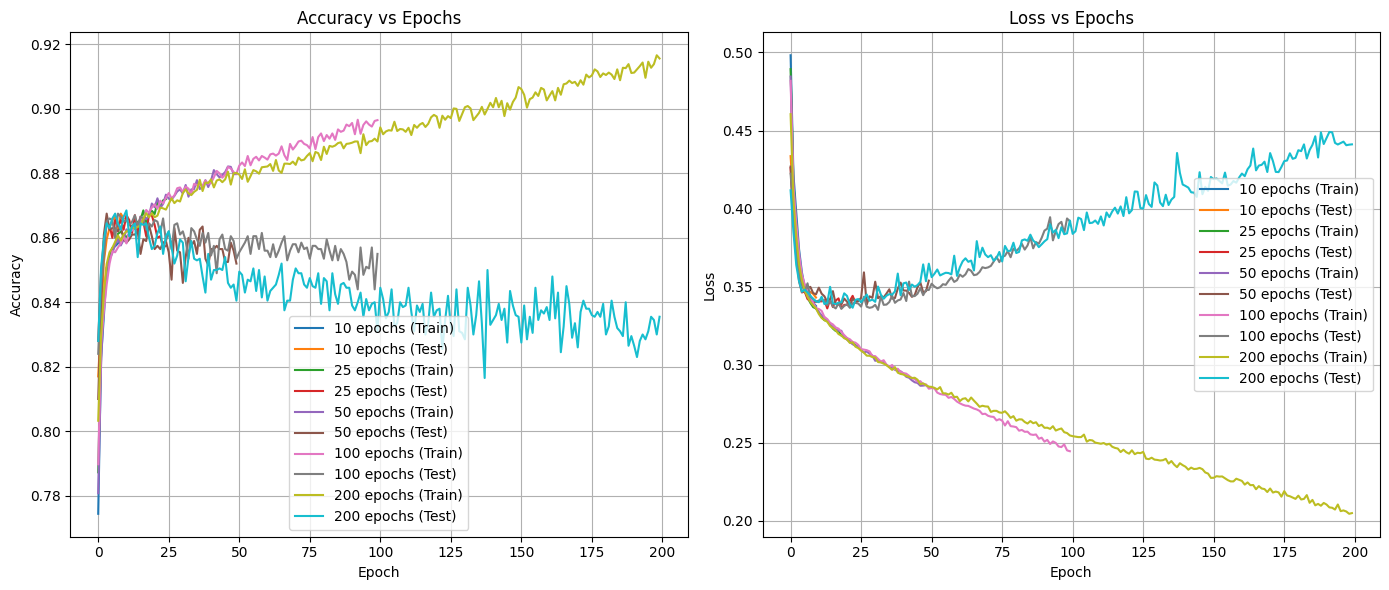


--- Summary of Test Accuracies ---
Epochs: 10   | Test Accuracy: 0.8660
Epochs: 25   | Test Accuracy: 0.8575
Epochs: 50   | Test Accuracy: 0.8520
Epochs: 100  | Test Accuracy: 0.8550
Epochs: 200  | Test Accuracy: 0.8355


In [69]:
import matplotlib.pyplot as plt

# Define a function to create the standard ANN model
def create_model():
    model = Sequential()
    model.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu', input_dim=10))
    model.add(Dense(units=64, kernel_initializer='glorot_uniform', activation='relu'))
    model.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

epoch_counts = [10, 25, 50, 100, 200]
histories = {}
accuracies_test = {}

print("\n--- Training ANN with different epoch counts ---")
for epochs in epoch_counts:
    print(f"\nTraining for {epochs} epochs...")
    classifier = create_model()
    # Train the model and store the history
    history = classifier.fit(x_train, y_train, batch_size=100, epochs=epochs, verbose=0, validation_data=(x_test, y_test))
    histories[epochs] = history

    # Evaluate on test set
    y_pred = (classifier.predict(x_test) > 0.5)
    current_accuracy = accuracy_score(y_test, y_pred)
    accuracies_test[epochs] = current_accuracy
    print(f"Test Accuracy after {epochs} epochs: {current_accuracy:.4f}")


# Accuracy vs Epoch
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
for epochs, history in histories.items():
    plt.plot(history.history['accuracy'], label=f'{epochs} epochs (Train)')
    plt.plot(history.history['val_accuracy'], label=f'{epochs} epochs (Test)')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

#Loss vs Epoch
plt.subplot(1, 2, 2)
for epochs, history in histories.items():
    plt.plot(history.history['loss'], label=f'{epochs} epochs (Train)')
    plt.plot(history.history['val_loss'], label=f'{epochs} epochs (Test)')
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Summary of Test Accuracies ---")
for epochs, acc in accuracies_test.items():
    print(f"Epochs: {epochs:<4} | Test Accuracy: {acc:.4f}")

In [70]:
batch_sizes = [8, 16, 32, 64, 128]
accuracies_batch_size = {}

print("\n--- Training ANN with different Batch Sizes ---")
for batch_size in batch_sizes:
    print(f"\nTraining for batch size {batch_size}...")
    classifier = create_model()
    classifier.fit(x_train, y_train, batch_size=batch_size, epochs=20, verbose=0)

    y_pred = (classifier.predict(x_test) > 0.5)
    current_accuracy = accuracy_score(y_test, y_pred)
    accuracies_batch_size[batch_size] = current_accuracy
    print(f"Test Accuracy with batch size {batch_size}: {current_accuracy:.4f}")

print("\n--- Summary of Test Accuracies for Different Batch Sizes ---")
for bs, acc in accuracies_batch_size.items():
    print(f"Batch Size: {bs:<5} | Test Accuracy: {acc:.4f}")


--- Training ANN with different Batch Sizes ---

Training for batch size 8...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy with batch size 8: 0.8590

Training for batch size 16...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy with batch size 16: 0.8565

Training for batch size 32...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy with batch size 32: 0.8525

Training for batch size 64...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy with batch size 64: 0.8535

Training for batch size 128...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy with batch size 128: 0.8565

--- Summary of Test Accuracies for Different Batch Sizes ---
Batch Size: 8     | Test Accuracy: 0.8590
Batch Size: 16    | Test Accuracy: 0.8565
Batch Size: 32    | Test Accuracy: 0.8525
Batch Size: 64    | Test Accuracy: 0.8535
Batch Size: 128   | Test Accuracy: 0.8565


In [71]:
from keras.layers import Dropout

def create_improved_model():
    model = Sequential()

    model.add(Dense(units=128, kernel_initializer='glorot_uniform', activation='relu', input_dim=10))
    model.add(Dropout(rate=0.3))

    model.add(Dense(units=128, kernel_initializer='glorot_uniform', activation='relu'))
    model.add(Dropout(rate=0.3))

    model.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

improved_classifier = create_improved_model()

print("\n--- Training the Improved ANN Model ---")
history_improved = improved_classifier.fit(x_train, y_train, batch_size=100, epochs=100, verbose=1, validation_data=(x_test, y_test))

y_pred_improved = (improved_classifier.predict(x_test) > 0.5)
accuracy_improved = accuracy_score(y_test, y_pred_improved)
cm_improved = confusion_matrix(y_test, y_pred_improved)

print(f"\nConfusion Matrix (Improved Model):\n{cm_improved}")
print(f"Accuracy (Improved Model): {accuracy_improved:.4f}")


--- Training the Improved ANN Model ---
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7950 - loss: 0.4789 - val_accuracy: 0.8265 - val_loss: 0.4215
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8199 - loss: 0.4224 - val_accuracy: 0.8490 - val_loss: 0.3909
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8339 - loss: 0.4006 - val_accuracy: 0.8610 - val_loss: 0.3693
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8430 - loss: 0.3818 - val_accuracy: 0.8650 - val_loss: 0.3578
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8425 - loss: 0.3749 - val_accuracy: 0.8605 - val_loss: 0.3550
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8478 - loss: 0.3660 - val_accuracy: 0.8650 - val_loss: 0.3480
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8506 - loss: 0.3607 - val_accuracy: 0.8645 - val_loss: 0.3486
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8510

In [72]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, ELU
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from keras.utils import plot_model
import matplotlib.pyplot as plt

best_model = Sequential()

best_model.add(Dense(units=128, kernel_initializer='random_normal', input_dim=x_train.shape[1]))
best_model.add(ELU())
best_model.add(Dropout(rate=0.3))

best_model.add(Dense(units=64, kernel_initializer='random_normal'))
best_model.add(ELU())
best_model.add(Dropout(rate=0.3))

best_model.add(Dense(units=32, kernel_initializer='random_normal'))
best_model.add(ELU())
best_model.add(Dropout(rate=0.2))

best_model.add(Dense(units=1, kernel_initializer='random_normal', activation='sigmoid'))
best_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- Training the Best ANN Model ---")
history_best_model = best_model.fit(x_train, y_train, batch_size=8, epochs=50, verbose=1, validation_data=(x_test, y_test))


--- Training the Best ANN Model ---
Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8060 - loss: 0.4551 - val_accuracy: 0.8215 - val_loss: 0.4205
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8249 - loss: 0.4047 - val_accuracy: 0.8520 - val_loss: 0.3697
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8376 - loss: 0.3874 - val_accuracy: 0.8595 - val_loss: 0.3588
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8432 - loss: 0.3806 - val_accuracy: 0.8515 - val_loss: 0.3657
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8451 - loss: 0.3771 - val_accuracy: 0.8640 - val_loss: 0.3481
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8424 - loss: 0.3777 - val_accuracy: 0.8655 - val_loss: 0.3518
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8508 - loss: 0.3684 - val_accuracy: 0.8580 - val_loss: 0.3504
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step 

In [73]:
y_pred_best_model = (best_model.predict(x_test) > 0.5)

accuracy_best_model = accuracy_score(y_test, y_pred_best_model)
cm_best_model = confusion_matrix(y_test, y_pred_best_model)
classification_rep_best_model = classification_report(y_test, y_pred_best_model)

print(f"\n--- Best Model Evaluation ---")
print(f"Accuracy (Best Model): {accuracy_best_model:.4f}")
print(f"\nConfusion Matrix (Best Model):\n{cm_best_model}")
print(f"\nClassification Report (Best Model):\n{classification_rep_best_model}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Best Model Evaluation ---
Accuracy (Best Model): 0.8655

Confusion Matrix (Best Model):
[[1541   54]
 [ 215  190]]

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1595
           1       0.78      0.47      0.59       405

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000




--- Best Model Architecture ---


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_116 (Dense)               │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_2 (ELU)                     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_3 (ELU)                     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_4 (ELU)                     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,333 (138.02 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,556 (92.02 KB)

Model architecture saved to best_model_architecture.png


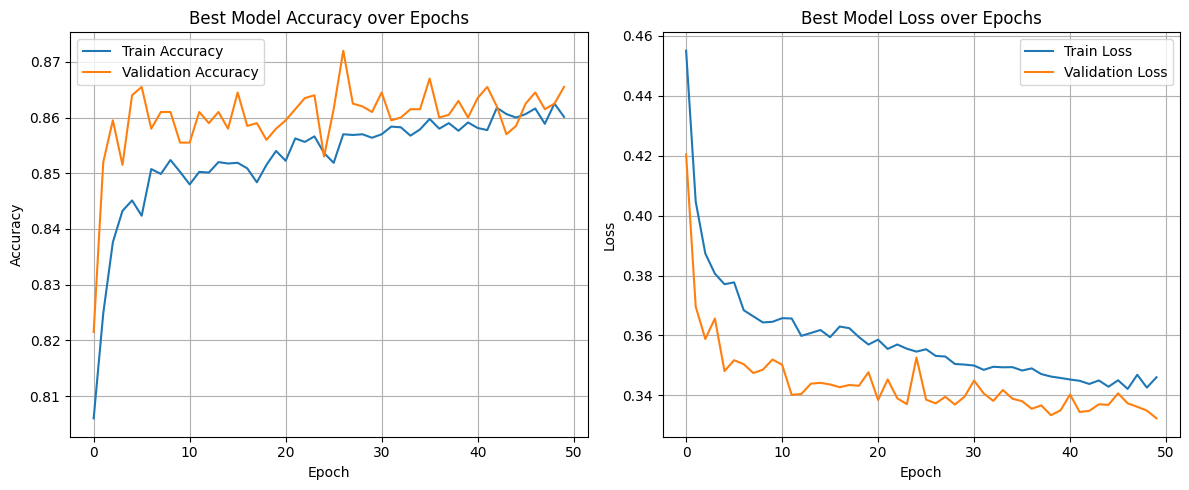

In [74]:
print("\n--- Best Model Architecture ---")
best_model.summary()
plot_model(best_model, to_file='best_model_architecture.png', show_shapes=True, show_layer_names=True)
print("Model architecture saved to best_model_architecture.png")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_best_model.history['accuracy'], label='Train Accuracy')
plt.plot(history_best_model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Best Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_best_model.history['loss'], label='Train Loss')
plt.plot(history_best_model.history['val_loss'], label='Validation Loss')
plt.title('Best Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()